# Dinosaur Genera Dataset Exploration

## Summary 

In this notebook i want to explore the [dinosaur genera dataset](https://www.kaggle.com/datasets/canozensoy/dinosaur-genera-dataset/data).

### Questions

- Relation size diet
- Relation size time period

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

dinosaur_df = pd.read_csv('../Datasets/archive/dinoDatasetCSV.csv')
dinosaur_df.head()

,scientific_name,common_name,meaning,diet,length_m,weight_kg,height_m,locomotion,geological_period,lived_in,behavior_notes,first_discovered,fossil_location,notable_features,intelligence_level,source_link,row_index
0,Abelisaurus,Abelisaurus,Abel's lizard,Carnivore,7.0,1500.0,2.4,Bipedal,Late Cretaceous,Argentina,Large theropod,1985,Argentina,Short arms,Medium,https://en.wikipedia.org/wiki/Abelisaurus,0
1,Abrictosaurus,Abrictosaurus,Wakeful lizard,Herbivore,1.5,15.0,0.5,Bipedal,Early Jurassic,South Africa,Small herbivore,1974,South Africa,Unique teeth,Medium,https://en.wikipedia.org/wiki/Abrictosaurus,1
2,Abrosaurus,Abrosaurus,Delicate lizard,Herbivore,9.0,2000.0,4.5,Quadrupedal,Middle Jurassic,China,Delicate skull,1959,China,Delicate skull,Medium,https://en.wikipedia.org/wiki/Abrosaurus,2
3,Abydosaurus,Abydosaurus,Abydos lizard,Herbivore,18.0,30000.0,6.0,Quadrupedal,Early Cretaceous,USA,Basal sauropod,2010,USA,Complete skull,Medium,https://en.wikipedia.org/wiki/Abydosaurus,3
4,Acantholipan,Acantholipan,Spiny shield,Herbivore,5.0,2500.0,1.5,Quadrupedal,Late Cretaceous,Mexico,Armored nodosaur,2011,Mexico,Clubless armored tail,Medium,https://en.wikipedia.org/wiki/Acantholipan,4


In [2]:
print(dinosaur_df.info())
print("___________________________")
dinosaur_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1542 entries, 0 to 1541
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   scientific_name     1542 non-null   object 
 1   common_name         1542 non-null   object 
 2   meaning             1542 non-null   object 
 3   diet                1542 non-null   object 
 4   length_m            1503 non-null   float64
 5   weight_kg           1504 non-null   float64
 6   height_m            1510 non-null   float64
 7   locomotion          1542 non-null   object 
 8   geological_period   1542 non-null   object 
 9   lived_in            1542 non-null   object 
 10  behavior_notes      1542 non-null   object 
 11  first_discovered    1542 non-null   object 
 12  fossil_location     1542 non-null   object 
 13  notable_features    1542 non-null   object 
 14  intelligence_level  1542 non-null   object 
 15  source_link         1542 non-null   object 
 16  row_in

,length_m,weight_kg,height_m,row_index
count,1503.000000,1504.000000,1510.000000,1542.000000
mean,6.691397,3827.900625,2.377947,770.500000
std,5.493007,7510.800693,1.685147,445.281372
min,0.300000,0.100000,0.100000,0.000000
25%,2.500000,100.000000,1.000000,385.250000
50%,6.000000,1500.000000,2.000000,770.500000
75%,9.000000,3500.000000,3.000000,1155.750000
max,37.000000,75000.000000,12.000000,1541.000000


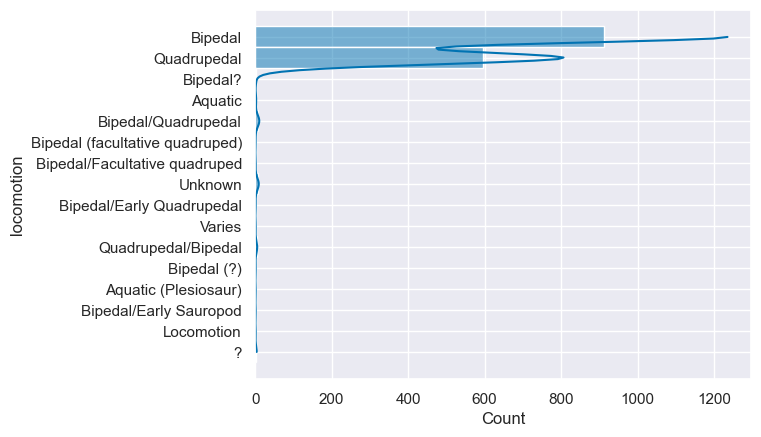

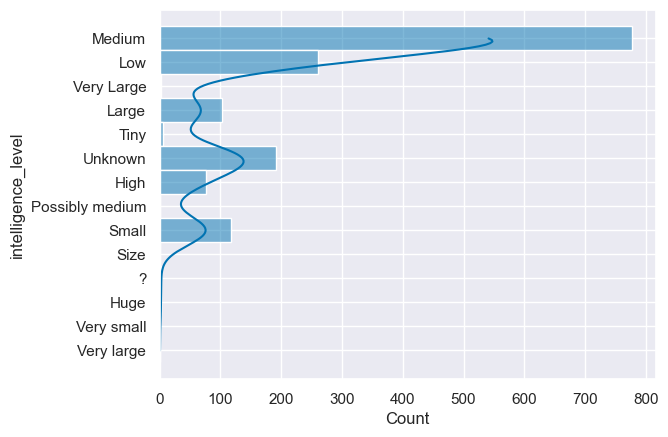

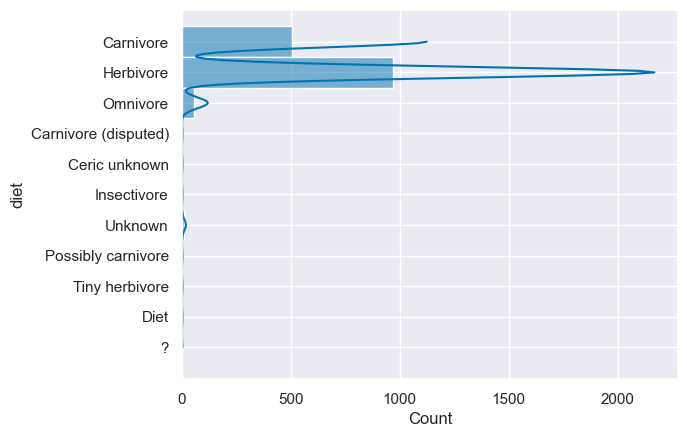

In [81]:
list=["locomotion","intelligence_level","diet"]

#fig, axes = plt.subplots(3, 2, figsize=(16, 10))
plt.tight_layout(w_pad=10)


for feature in list:
    sns.set_theme(font_scale=1,style="darkgrid")
    sns.set_palette("colorblind")
    g=sns.histplot( y=dinosaur_df[feature],kde=True)
    #plt.title("Distribution of Diets")
    plt.show()


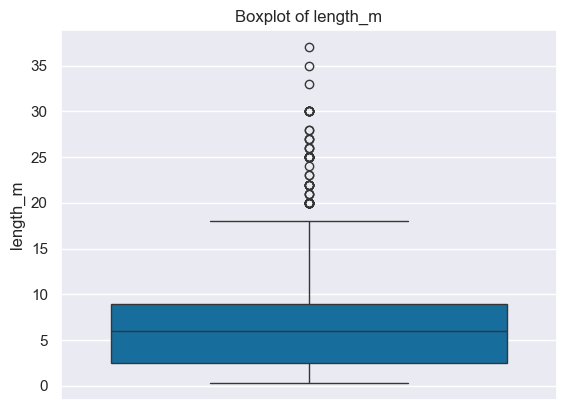

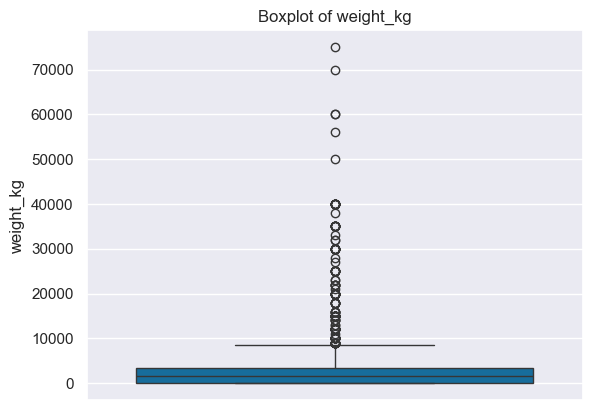

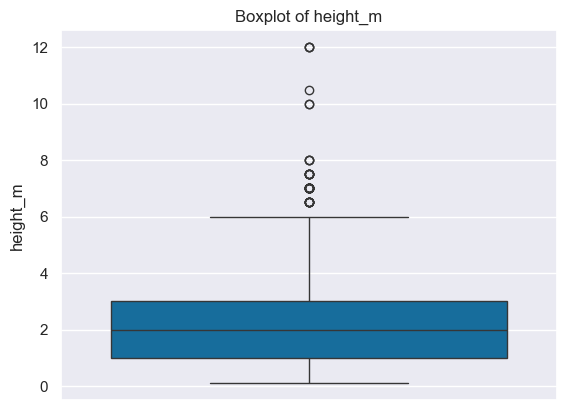

In [90]:
# Looking for outliers in numeric columns
list=["length_m","weight_kg","height_m"]

for x in list:
    plt.title(f"Boxplot of {x}")
    sns.boxplot(data=dinosaur_df,y=x)
    plt.show()

geological_period
Late Cretaceous                              659
Late Jurassic                                206
Early Cretaceous                             106
Early Jurassic                                86
Late Cretaceous (Maastrichtian)               48
Late Triassic                                 47
Late Cretaceous (Campanian)                   46
Jurassic                                      45
Middle Jurassic                               36
Cretaceous                                    26
Early Cretaceous (Aptian)                     24
Early Cretaceous (Barremian)                  18
Late Cretaceous (Cenomanian)                  16
Late Jurassic (Kimmeridgian)                  15
Late Jurassic (Oxfordian)                     13
Late Cretaceous (Campanian–Maastrichtian)     11
Name: count, dtype: int64


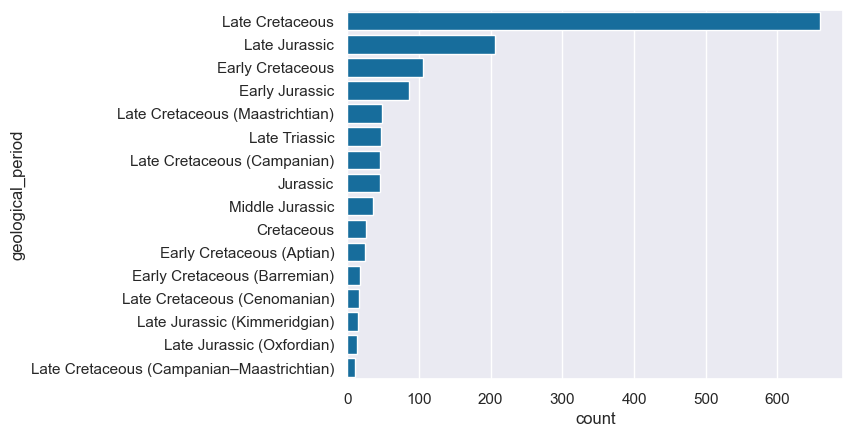

In [117]:
# Geololigal periods over with over 10 occurences
s=pd.DataFrame(dinosaur_df.value_counts("geological_period"))
s2 = s[s["count"]>10]
sns.barplot(y=s2.index,x=s2["count"])
print(s2["count"])
plt.show()

## Data Wrangling

For further investigations i want to include the time when the fossils have been found. Therefore I compresse the time in to decades.

In [185]:
#dinosaur_df.value_counts("first_discovered",ascending=True)
#x = np.floor(dinosaur_df["first_discovered"]/10)
dinosaur_df["cleaned_time"] = pd.to_numeric(dinosaur_df["first_discovered"],errors="coerce")
df = dinosaur_df.dropna(subset=["cleaned_time"])
df["decade"] = np.floor(df["cleaned_time"]/10)*10
df["decade"] = df["decade"].astype("int")


C:\Users\kyild\AppData\Local\Temp\ipykernel_8676\3883831955.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["decade"] = np.floor(df["cleaned_time"]/10)*10
C:\Users\kyild\AppData\Local\Temp\ipykernel_8676\3883831955.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["decade"] = df["decade"].astype("int")


In [231]:
time_df = pd.DataFrame(df["decade"].value_counts())

count    3
Name: 1830, dtype: int64

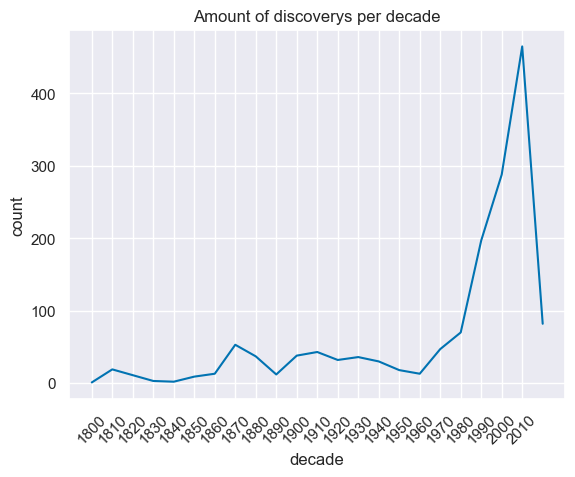

In [232]:
#g= sns.lineplot(x=df["decade"].value_counts().index,y=df["decade"].value_counts().values)
g= sns.lineplot(data=time_df,x="decade",y="count")
plt.xticks(np.arange(min(time_df.index),max(time_df.index),10))
plt.title("Amount of discoverys per decade")
plt.xticks(rotation=45)
plt.show()

### Relation between size and diet


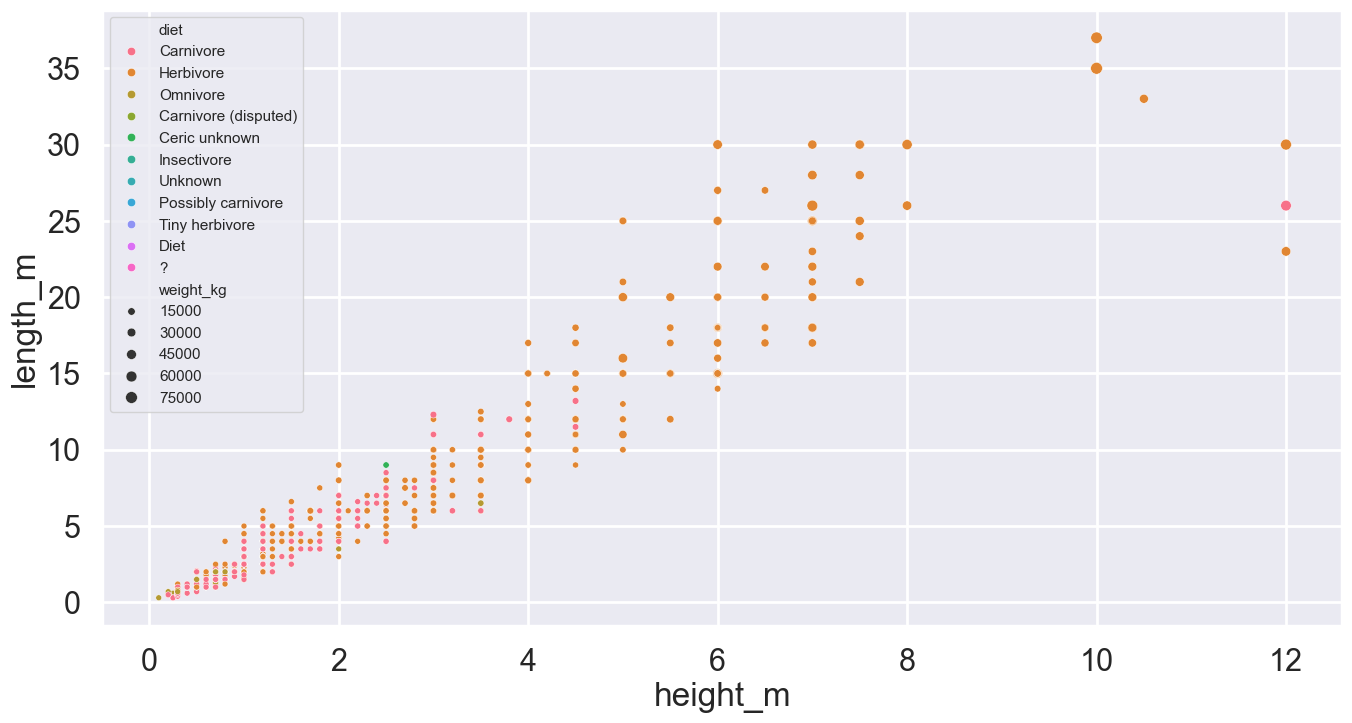

In [319]:
fig,ax= plt.subplots(figsize=(16,8))
sns.set_context('poster')
sns.set_theme(font_scale=1)
sns.scatterplot(data=dinosaur_df,x="height_m",y="length_m",hue="diet",size="weight_kg")
plt.show()